# Flight Price Exploratory Data Analysis

## Portfolio case study

This project explores **round-trip flight prices from Edmonton (YEG)** for a fixed travel window: **November 23 to December 5, 2026**.

I created this project as a junior data analytics portfolio case study. The goal is to show a clear workflow: define a practical question, collect data, inspect and clean it, engineer useful variables, visualize the results, and communicate limitations.

### Business objective

A traveler in Edmonton wants to compare popular destinations in Central America, South America, the Caribbean, and Iceland and identify lower-cost options for the same travel dates.

I first searched a shortlist of 30 popular airports, then verified the 10 cheapest results individually. This notebook analyzes that verified top-10 snapshot.

### Questions I wanted to answer

- Which destinations had the lowest round-trip fares?
- How large is the price difference between the cheapest and most expensive options in the verified top 10?
- Is a lower fare associated with more stops?
- Is a lower fare associated with a longer outbound itinerary?
- Which airlines appear most often in the cheapest group?
- What are the main limitations of using a single-date flight-price snapshot?

### Tools demonstrated

`Python` · `pandas` · `NumPy` · `Matplotlib` · `requests` · `JSON` · `Jupyter Notebook`

> **Data note:** Flight prices are dynamic. The saved CSV is a snapshot collected for this learning project and should not be treated as a live fare quote.

## 1. Import libraries and load the saved data

I keep the analyzed results in a CSV inside the repository. This makes the notebook reproducible for someone viewing it on GitHub and avoids requiring an API key just to run the exploratory analysis.

`Path` lets the notebook find the CSV whether it is run from the repository root or from a nearby working directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_path = Path("data/verified_top10_flights.csv")

if not data_path.exists():
    data_path = Path("verified_top10_flights.csv")

df = pd.read_csv(data_path)

## 2. Initial data inspection

Before analyzing the data, I check the first rows, shape, data types, summary statistics, and missing values.

This is a basic but important analyst habit: **understand the dataset before making conclusions from it.**

In [3]:
df.head()

,destination,city,country,price_cad,airline,outbound_stops,outbound_duration_minutes
0,PUJ,Punta Cana,Dominican Republic,529,WestJet,0,420
1,MBJ,Montego Bay,Jamaica,544,WestJet,1,1140
2,BZE,Belize City,Belize,550,WestJet,1,510
3,NAS,Nassau,Bahamas,615,Air Canada,1,550
4,SXM,Sint Maarten,Sint Maarten (Dutch part),628,WestJet,2,910


In [4]:
df.shape

(10, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   destination                10 non-null     object
 1   city                       10 non-null     object
 2   country                    10 non-null     object
 3   price_cad                  10 non-null     int64 
 4   airline                    10 non-null     object
 5   outbound_stops             10 non-null     int64 
 6   outbound_duration_minutes  10 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 692.0+ bytes


In [6]:
df.describe(include="all")

,destination,city,country,price_cad,airline,outbound_stops,outbound_duration_minutes
count,10,10,10,10.000000,10,10.000000,10.000000
unique,10,10,10,NaN,3,NaN,NaN
top,PUJ,Punta Cana,Dominican Republic,NaN,WestJet,NaN,NaN
freq,1,1,1,NaN,6,NaN,NaN
mean,NaN,NaN,NaN,627.900000,NaN,1.100000,737.200000
std,NaN,NaN,NaN,70.284264,NaN,0.567646,222.074962
min,NaN,NaN,NaN,529.000000,NaN,0.000000,420.000000
25%,NaN,NaN,NaN,566.250000,NaN,1.000000,553.750000
50%,NaN,NaN,NaN,630.000000,NaN,1.000000,780.000000
75%,NaN,NaN,NaN,670.750000,NaN,1.000000,869.250000


In [7]:
df.isna().sum()

destination                  0
city                         0
country                      0
price_cad                    0
airline                      0
outbound_stops               0
outbound_duration_minutes    0
dtype: int64

### What I learned from the initial inspection

The saved dataset contains **10 verified destinations**. Each row represents the lowest fare found for one destination in the final verification step.

Important fields include:

- `price_cad` — round-trip fare in Canadian dollars.
- `outbound_stops` — number of stops in the outbound itinerary returned with the fare.
- `outbound_duration_minutes` — total outbound itinerary duration.
- `airline` — airline associated with the returned outbound itinerary.

The sample is intentionally small because it contains only the verified top 10, not every possible airport. This means the analysis is useful for comparison, but it should not be generalized to the entire flight market.

## 3. Data-quality checks

Before visualizing the data, I check for duplicate destinations, non-positive prices, and impossible negative duration or stop values.

These checks are simple, but they help prevent obvious data issues from affecting the analysis.

In [8]:
print("Duplicate destination codes:", df["destination"].duplicated().sum())
print("Non-positive prices:", (df["price_cad"] <= 0).sum())
print("Negative stop counts:", (df["outbound_stops"] < 0).sum())
print("Non-positive durations:", (df["outbound_duration_minutes"] <= 0).sum())

Duplicate destination codes: 0
Non-positive prices: 0
Negative stop counts: 0
Non-positive durations: 0


### Interpretation: data quality

The saved verified sample should contain one row per destination and positive values for price and duration. If any of these checks return unexpected values, I would investigate those rows before continuing.

I do **not** assume that a clean-looking table means the market data itself is complete. A flight search can still omit fares, change over time, or return different itineraries later.

## 4. Feature engineering

Minutes are useful for calculations but harder to read. I convert outbound duration to hours and create a simple price rank.

Feature engineering makes the dataset easier to interpret without changing the underlying observations.

In [9]:
df["outbound_duration_hours"] = (
    df["outbound_duration_minutes"] / 60
).round(1)

df["price_rank"] = (
    df["price_cad"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

df = df.sort_values("price_cad").reset_index(drop=True)

df.head()

,destination,city,country,price_cad,airline,outbound_stops,outbound_duration_minutes,outbound_duration_hours,price_rank
0,PUJ,Punta Cana,Dominican Republic,529,WestJet,0,420,7.0,1
1,MBJ,Montego Bay,Jamaica,544,WestJet,1,1140,19.0,2
2,BZE,Belize City,Belize,550,WestJet,1,510,8.5,3
3,NAS,Nassau,Bahamas,615,Air Canada,1,550,9.2,4
4,SXM,Sint Maarten,Sint Maarten (Dutch part),628,WestJet,2,910,15.2,5


## 5. Rank destinations by round-trip price

The main business question is straightforward: for the same travel dates, which verified destinations had the lowest fares?

In [10]:
price_table = df[
    [
        "price_rank",
        "destination",
        "city",
        "country",
        "price_cad",
        "airline",
        "outbound_stops",
        "outbound_duration_hours"
    ]
]

price_table

,price_rank,destination,city,country,price_cad,airline,outbound_stops,outbound_duration_hours
0,1,PUJ,Punta Cana,Dominican Republic,529,WestJet,0,7.0
1,2,MBJ,Montego Bay,Jamaica,544,WestJet,1,19.0
2,3,BZE,Belize City,Belize,550,WestJet,1,8.5
3,4,NAS,Nassau,Bahamas,615,Air Canada,1,9.2
4,5,SXM,Sint Maarten,Sint Maarten (Dutch part),628,WestJet,2,15.2
5,6,UVF,Vieux Fort,Saint Lucia,632,WestJet,2,14.7
6,7,LIM,Lima,Peru,667,United,1,14.0
7,8,SJU,San Juan,Puerto Rico,672,United,1,9.4
8,9,POS,Port of Spain,Trinidad and Tobago,704,United,1,13.3
9,10,GCM,George Town,Cayman Islands,738,WestJet,1,12.7


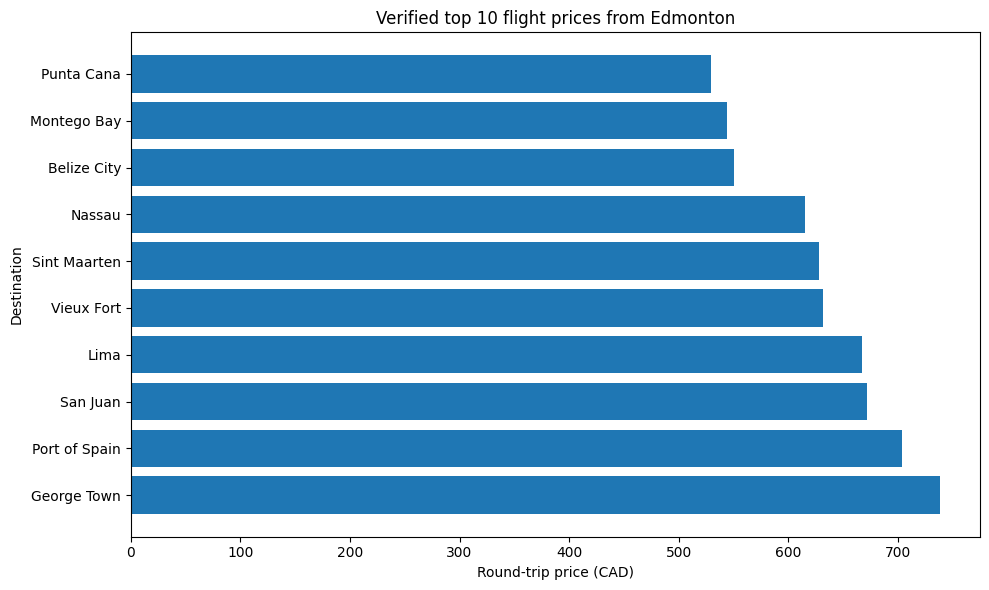

In [11]:
plt.figure(figsize=(10, 6))

plt.barh(df["city"], df["price_cad"])
plt.gca().invert_yaxis()

plt.xlabel("Round-trip price (CAD)")
plt.ylabel("Destination")
plt.title("Verified top 10 flight prices from Edmonton")

plt.tight_layout()
plt.show()

### Interpretation: cheapest destinations

**Punta Cana (PUJ) is the lowest-priced verified option at CAD 529**, followed by **Montego Bay at CAD 544** and **Belize City at CAD 550**.

The most expensive destination in this verified top-10 group is **Grand Cayman at CAD 738**.

The difference between the cheapest and most expensive options is large enough to matter for a budget traveler, even though all destinations use exactly the same departure and return dates.

## 6. Price distribution

A histogram and boxplot help show how tightly the ten fares are grouped and whether one or two destinations are unusually expensive relative to the rest.

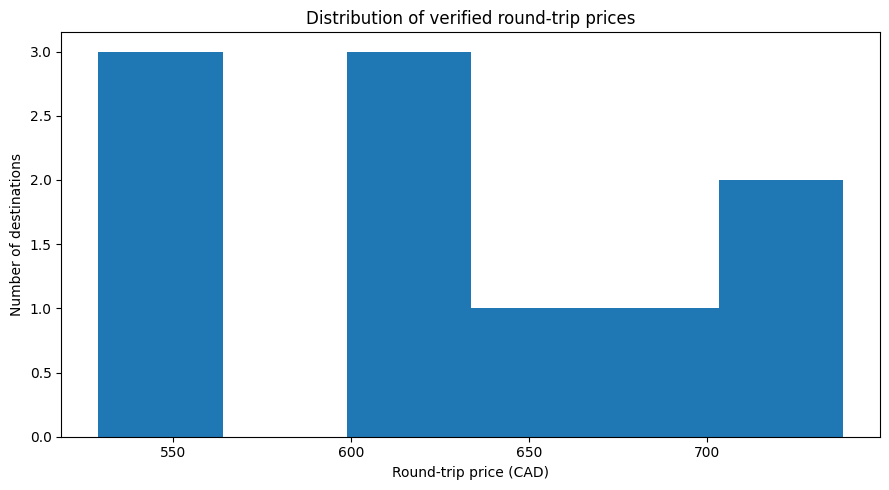

In [12]:
plt.figure(figsize=(9, 5))

plt.hist(df["price_cad"], bins=6)

plt.xlabel("Round-trip price (CAD)")
plt.ylabel("Number of destinations")
plt.title("Distribution of verified round-trip prices")

plt.tight_layout()
plt.show()

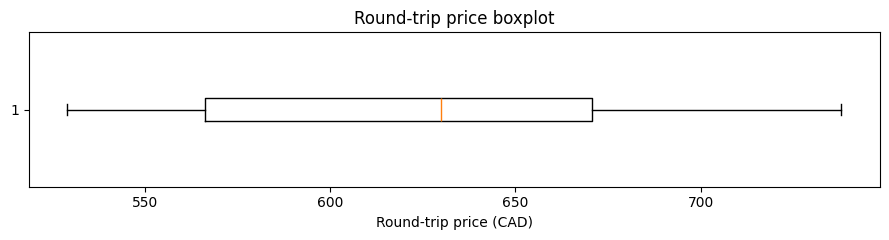

In [13]:
plt.figure(figsize=(9, 2.5))

plt.boxplot(df["price_cad"], vert=False)

plt.xlabel("Round-trip price (CAD)")
plt.title("Round-trip price boxplot")

plt.tight_layout()
plt.show()

### Interpretation: price distribution

The verified fares range from the low CAD 500s to the high CAD 700s. Because there are only ten observations, I would not use this sample to make strong claims about the statistical distribution of international flight prices.

For this project, the charts are mainly useful for showing the spread of the shortlist and identifying the relative position of each fare.

## 7. Price difference from the cheapest option

A traveler may care more about the **extra amount paid compared with the cheapest destination** than about the raw fare alone.

In [14]:
cheapest_price = df["price_cad"].min()

df["extra_vs_cheapest"] = df["price_cad"] - cheapest_price

df[
    ["destination", "city", "price_cad", "extra_vs_cheapest"]
]

,destination,city,price_cad,extra_vs_cheapest
0,PUJ,Punta Cana,529,0
1,MBJ,Montego Bay,544,15
2,BZE,Belize City,550,21
3,NAS,Nassau,615,86
4,SXM,Sint Maarten,628,99
5,UVF,Vieux Fort,632,103
6,LIM,Lima,667,138
7,SJU,San Juan,672,143
8,POS,Port of Spain,704,175
9,GCM,George Town,738,209


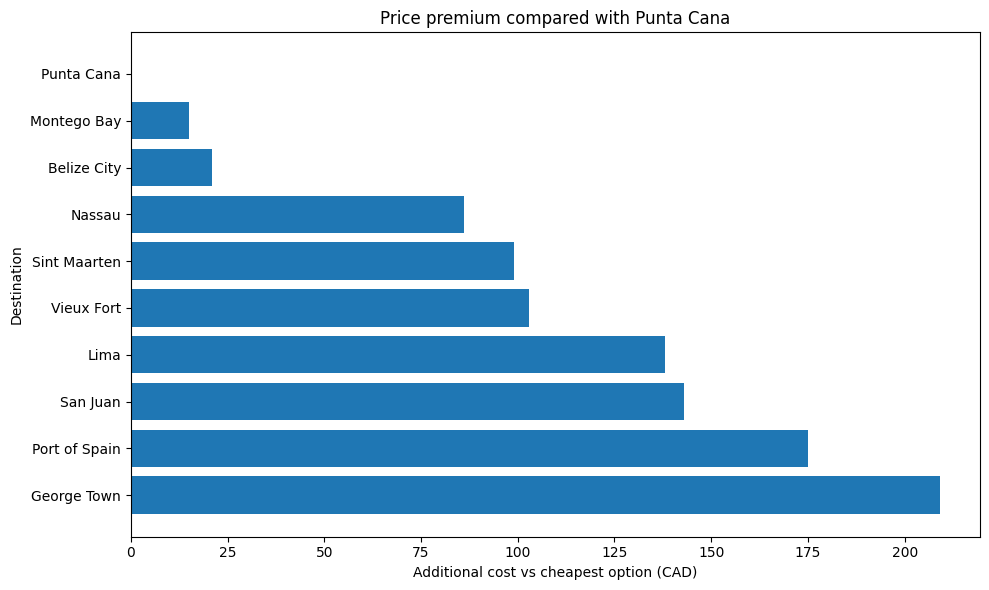

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(df["city"], df["extra_vs_cheapest"])
plt.gca().invert_yaxis()

plt.xlabel("Additional cost vs cheapest option (CAD)")
plt.ylabel("Destination")
plt.title("Price premium compared with Punta Cana")

plt.tight_layout()
plt.show()

### Interpretation: price premium

The first three destinations are relatively close in price. After that, the premium increases.

This type of comparison is useful for a practical travel decision: a traveler may decide that paying an extra CAD 20–40 for a preferred destination is reasonable, while an extra CAD 150–200 may change the decision.

## 8. Stops and price

Cheaper tickets sometimes require less convenient itineraries. I group the verified results by number of outbound stops and compare the average fare.

Because the groups are very small, this is descriptive only.

In [16]:
stops_summary = (
    df.groupby("outbound_stops")
      .agg(
          destinations=("destination", "count"),
          average_price_cad=("price_cad", "mean"),
          median_price_cad=("price_cad", "median")
      )
      .round(1)
)

stops_summary

,destinations,average_price_cad,median_price_cad
outbound_stops,,,
0,1,529.0,529.0
1,7,641.4,667.0
2,2,630.0,630.0


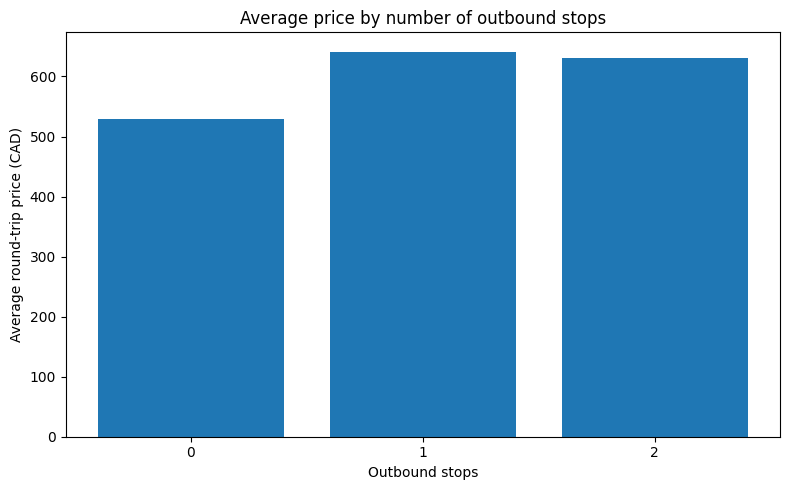

In [17]:
avg_price_by_stops = (
    df.groupby("outbound_stops")["price_cad"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(avg_price_by_stops.index.astype(str), avg_price_by_stops.values)

plt.xlabel("Outbound stops")
plt.ylabel("Average round-trip price (CAD)")
plt.title("Average price by number of outbound stops")

plt.tight_layout()
plt.show()

### Interpretation: stops

The cheapest fare in the sample is also the only nonstop itinerary in the verified top 10. However, this does **not** prove that nonstop flights are generally cheaper.

The sample was selected because these were already among the cheapest destinations, so it has selection bias. A stronger analysis would compare many fares within each destination and route.

## 9. Outbound itinerary duration

Price is not the only travel cost. A cheaper fare can involve a much longer journey.

I compare round-trip price with the outbound itinerary duration returned for each fare.

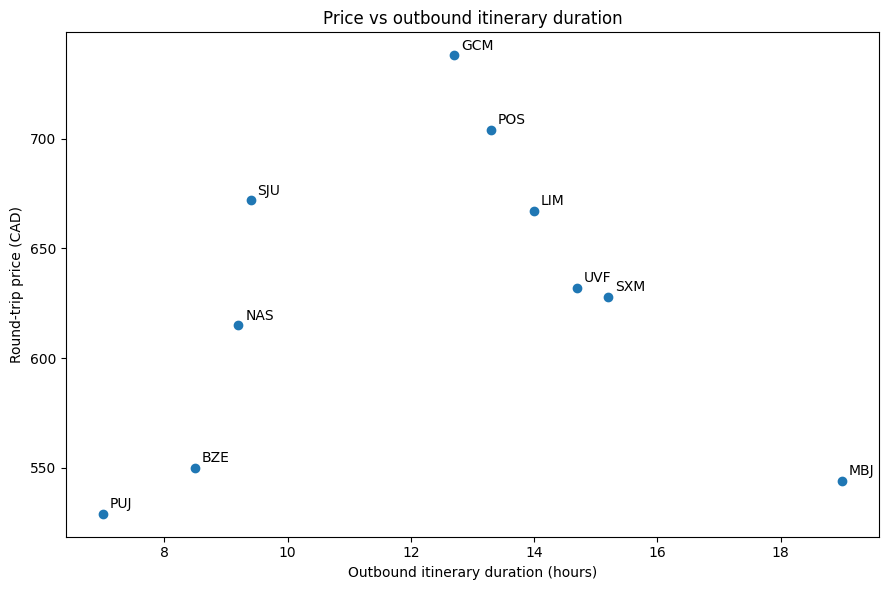

In [18]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["outbound_duration_hours"],
    df["price_cad"]
)

for _, row in df.iterrows():
    plt.annotate(
        row["destination"],
        (row["outbound_duration_hours"], row["price_cad"]),
        xytext=(5, 4),
        textcoords="offset points"
    )

plt.xlabel("Outbound itinerary duration (hours)")
plt.ylabel("Round-trip price (CAD)")
plt.title("Price vs outbound itinerary duration")

plt.tight_layout()
plt.show()

In [19]:
df[
    [
        "destination",
        "city",
        "price_cad",
        "outbound_stops",
        "outbound_duration_hours"
    ]
].sort_values("outbound_duration_hours")

,destination,city,price_cad,outbound_stops,outbound_duration_hours
0,PUJ,Punta Cana,529,0,7.0
2,BZE,Belize City,550,1,8.5
3,NAS,Nassau,615,1,9.2
7,SJU,San Juan,672,1,9.4
9,GCM,George Town,738,1,12.7
8,POS,Port of Spain,704,1,13.3
6,LIM,Lima,667,1,14.0
5,UVF,Vieux Fort,632,2,14.7
4,SXM,Sint Maarten,628,2,15.2
1,MBJ,Montego Bay,544,1,19.0


### Interpretation: duration

The chart shows that price and itinerary duration do not move together in a simple way in this small sample.

For example, some relatively inexpensive destinations still have long outbound travel times. This is a practical reminder that the "best" flight is not always the lowest-priced flight.

A next step could create a simple value score that combines fare, travel time, and number of stops.

## 10. Airlines represented in the verified top 10

I count how often each airline appears in the returned cheapest itineraries.

This does not measure airline market share. It only describes this specific shortlist.

In [20]:
airline_counts = df["airline"].value_counts()

airline_counts

airline
WestJet       6
United        3
Air Canada    1
Name: count, dtype: int64

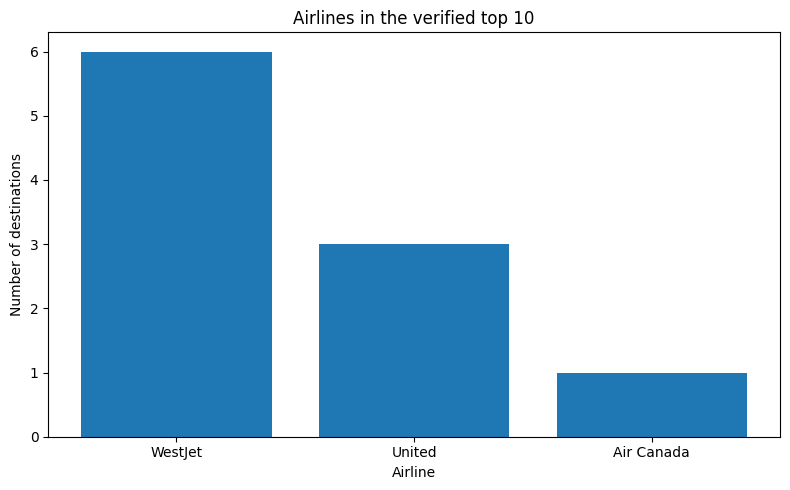

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(airline_counts.index, airline_counts.values)

plt.xlabel("Airline")
plt.ylabel("Number of destinations")
plt.title("Airlines in the verified top 10")

plt.tight_layout()
plt.show()

### Interpretation: airlines

WestJet appears most frequently in this verified shortlist, while United and Air Canada also appear.

This should not be interpreted as evidence that one airline is always cheaper. The result depends on the origin, exact dates, destination list, and the moment when the searches were performed.

## 11. Summary statistics for the shortlist

I calculate a few simple values that can be communicated quickly to a non-technical audience.

In [22]:
summary = pd.Series({
    "Cheapest fare (CAD)": df["price_cad"].min(),
    "Most expensive fare (CAD)": df["price_cad"].max(),
    "Median fare (CAD)": df["price_cad"].median(),
    "Average fare (CAD)": round(df["price_cad"].mean(), 1),
    "Price range (CAD)": df["price_cad"].max() - df["price_cad"].min()
})

summary

Cheapest fare (CAD)          529.0
Most expensive fare (CAD)    738.0
Median fare (CAD)            630.0
Average fare (CAD)           627.9
Price range (CAD)            209.0
dtype: float64

## 12. Key findings

1. **Punta Cana was the cheapest verified destination at CAD 529 round trip** for November 23 to December 5, 2026.
2. **Montego Bay (CAD 544) and Belize City (CAD 550)** were close behind, so the three cheapest choices were separated by only CAD 21.
3. The verified top-10 fares ranged from **CAD 529 to CAD 738**, a spread of **CAD 209**.
4. **Price alone does not measure travel convenience.** Several low-cost options still involve one or two stops and long outbound itineraries.
5. **WestJet appears most often** in this particular verified shortlist, but the sample is too narrow to make general airline-pricing conclusions.
6. The results are a **time-sensitive snapshot**. Repeating the same search on another day can produce different fares and itineraries.

## 13. Limitations

This project is intentionally a **junior-level exploratory analysis**, not a production airfare-pricing model.

Important limitations:

- Flight prices can change many times per day.
- The analysis uses one departure date and one return date.
- The final dataset contains only the verified top 10 from a manually selected list of 30 popular destinations.
- The shortlist does not represent every airport in the Americas or every possible destination.
- `outbound_stops` and `outbound_duration_minutes` describe the outbound itinerary returned with the fare; the round-trip fare itself covers the full trip.
- Search-engine results can change according to availability and the search provider's current data.
- Taxes, baggage, seat selection, fare restrictions, and booking conditions may affect the real trip cost.

Because of these limitations, I treat the results as exploratory evidence rather than a universal recommendation.

## 14. What I would do next

If I continued this project, I would:

- Collect the same 30 destinations repeatedly over several weeks.
- Add `search_date` and calculate `days_before_departure`.
- Compare Edmonton (YEG) with Calgary (YYC).
- Repeat the analysis for several travel periods instead of only one.
- Store a daily price history so I can study when fares tend to rise or fall.
- Compare the cheapest fare with the typical Google Flights price range.
- Add baggage information and total travel time when available.
- Build a simple dashboard in Tableau or Power BI.
- Only after collecting much more data, consider a predictive model for fare changes.

## Appendix A. Reproducible API collection pattern

The analysis above uses the saved CSV so that anyone can open the repository without an API key.

The following code shows the basic collection pattern I used with the Google Flights results returned through SerpApi. For security, I do **not** save the API key in the notebook or GitHub repository.

Set an environment variable named `SERPAPI_API_KEY` before running API requests.

In [23]:
import os
import requests

API_KEY = os.getenv("SERPAPI_API_KEY")

if API_KEY is None:
    print(
        "SERPAPI_API_KEY is not set. "
        "The saved CSV is enough to run the EDA sections above."
    )
else:
    print("API key found. Live requests can be enabled.")

SERPAPI_API_KEY is not set. The saved CSV is enough to run the EDA sections above.


In [24]:
# Example: one round-trip search.
# This cell does not run a request unless an API key is available.

if API_KEY:
    params = {
        "engine": "google_flights",
        "departure_id": "YEG",
        "arrival_id": "PUJ",
        "outbound_date": "2026-11-23",
        "return_date": "2026-12-05",
        "currency": "CAD",
        "hl": "en",
        "gl": "ca",
        "travel_class": "1",
        "type": "1",
        "adults": "1",
        "sort_by": "2",
        "api_key": API_KEY
    }

    response = requests.get(
        "https://serpapi.com/search.json",
        params=params,
        timeout=60
    )

    live_data = response.json()

    print(live_data.keys())
else:
    print("Skipped live request.")

Skipped live request.


### Why the API key is not stored in GitHub

API keys are credentials. Committing a real key to a public repository can expose the account to unauthorized use.

For a portfolio repository, I keep credentials outside the notebook and load them from an environment variable.